In [39]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB

from imblearn.over_sampling import SMOTE

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt

In [40]:
import pandas as pd

In [41]:
df = pd.read_csv("creditcard.csv")

In [42]:
X = df.drop(columns=['class'])
y = df['class']

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [44]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = X_train
X_test_scaled = X_test

# ONLY scale these columns
X_train_scaled[['Time', 'Amount']] = scaler.fit_transform(X_train[['Time', 'Amount']])
X_test_scaled[['Time', 'Amount']] = scaler.transform(X_test[['Time', 'Amount']])

In [45]:
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

In [46]:
model = GaussianNB()
model.fit(X_train_resampled, y_train_resampled)

,priors,None
,var_smoothing,1e-09


In [47]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:,1]

In [48]:
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print(cm)

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.05      0.88      0.10        98

    accuracy                           0.97     56962
   macro avg       0.53      0.93      0.55     56962
weighted avg       1.00      0.97      0.99     56962

[[55386  1478]
 [   12    86]]
ROC-AUC: 0.9644135703662444


In [49]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [50]:
cm = confusion_matrix(y_test, y_pred)

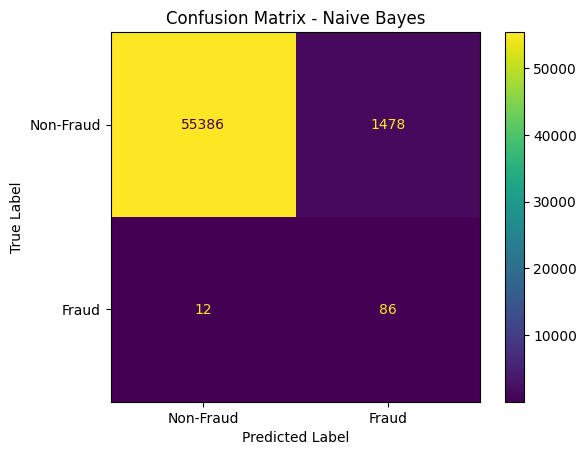

In [51]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Fraud", "Fraud"])
disp.plot(values_format='d')  # shows clean numbers

plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

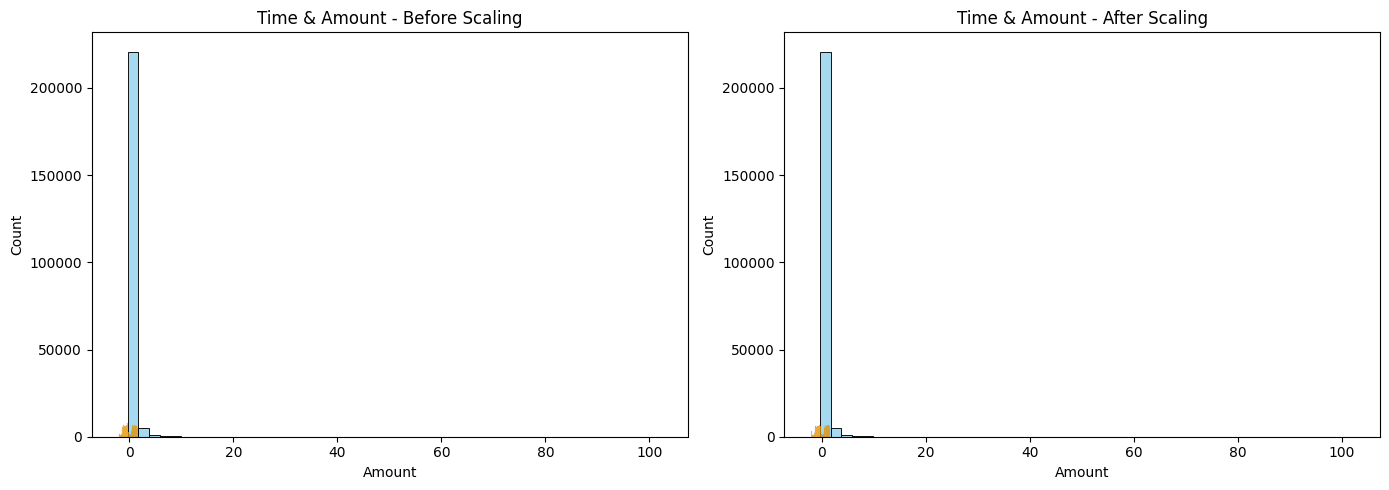

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Copy dataset
X_train_scaled = X_train.copy()

# Scale Time and Amount
scaler = StandardScaler()
X_train_scaled[['Time', 'Amount']] = scaler.fit_transform(X_train[['Time', 'Amount']])

# Plot before and after..
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Before scaling
sns.histplot(X_train['Amount'], bins=50, ax=axes[0], color='skyblue')
axes[0].set_title('Amount - Before Scaling')

sns.histplot(X_train['Time'], bins=50, ax=axes[0], color='orange')
axes[0].set_title('Time & Amount - Before Scaling')

# After scaling
sns.histplot(X_train_scaled['Amount'], bins=50, ax=axes[1], color='skyblue')
sns.histplot(X_train_scaled['Time'], bins=50, ax=axes[1], color='orange')
axes[1].set_title('Time & Amount - After Scaling')

plt.tight_layout()
plt.show()

In [53]:
best_threshold = 0.3
y_pred_final = (y_prob >= best_threshold).astype(int)

In [54]:
import numpy as np
from sklearn.metrics import recall_score, f1_score

thresholds = np.arange(0.1, 0.9, 0.1)

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    
    print(f"Threshold: {t}")
    print("Recall:", recall_score(y_test, y_pred_t))
    print("F1-score:", f1_score(y_test, y_pred_t))
    print("---------------------")

Threshold: 0.1
Recall: 0.8775510204081632
F1-score: 0.0977828311540648
---------------------
Threshold: 0.2
Recall: 0.8775510204081632
F1-score: 0.09976798143851508
---------------------
Threshold: 0.30000000000000004
Recall: 0.8775510204081632
F1-score: 0.10153482880755609
---------------------
Threshold: 0.4
Recall: 0.8775510204081632
F1-score: 0.10250297973778308
---------------------
Threshold: 0.5
Recall: 0.8775510204081632
F1-score: 0.10348977135980746
---------------------
Threshold: 0.6
Recall: 0.8775510204081632
F1-score: 0.10455927051671733
---------------------
Threshold: 0.7000000000000001
Recall: 0.8775510204081632
F1-score: 0.10565110565110565
---------------------
Threshold: 0.8
Recall: 0.8775510204081632
F1-score: 0.10696517412935323
---------------------


In [55]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy:", accuracy_score(y_test, y_pred_final))
print("Precision:", precision_score(y_test, y_pred_final))
print("Recall:", recall_score(y_test, y_pred_final))
print("F1-score:", f1_score(y_test, y_pred_final))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))  # ⚠️ use probabilities

Accuracy: 0.9732804325690811
Precision: 0.05388471177944862
Recall: 0.8775510204081632
F1-score: 0.10153482880755609
ROC-AUC: 0.9644135703662444
